# Analysis of Repeated Antibiotics

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import os
import glob
import gzip
from matplotlib.ticker import PercentFormatter
%matplotlib inline

In [53]:
current_working_dir = os.getcwd()
print(current_working_dir)

c:\Users\m84300af\OneDrive - The University of Manchester\Documents\GitHub\amr-uom-brit


In [54]:
def makeFilePath(pathFromWorkspace, fileName):
    workingdir = "/workspace/" if (os.name != "nt") else ""
    filepath = workingdir+pathFromWorkspace+fileName

    return filepath

In [55]:
input_20190101_file_path = makeFilePath("output/measures/", "input_2019-01-01.csv.gz")
data201901 = pd.read_csv(input_20190101_file_path, compression='gzip')
data201901['date'] = '2019-01-01'

In [56]:
input_20190201_file_path = makeFilePath("output/measures/", "input_2019-02-01.csv.gz")
data201902 = pd.read_csv(input_20190201_file_path, compression='gzip')
data201902['date'] = '2019-02-01'
data201902 = data201901.append(data201902, ignore_index=True)

In [57]:
input_20190301_file_path = makeFilePath("output/measures/", "input_2019-03-01.csv.gz")
data201903 = pd.read_csv(input_20190301_file_path, compression='gzip')
data201903['date'] = '2019-03-01'
data201903 = data201902.append(data201903, ignore_index=True)

In [58]:
input_20190401_file_path = makeFilePath("output/hospitalisation_data/", "input_hospitalisation_2019-04-01.csv.gz")
data201904 = pd.read_csv(input_20190401_file_path, compression='gzip')
data201904['date'] = '2019-04-01'
data = data201903.append(data201904, ignore_index=True)

In [48]:
# def read_csv_files(date, folder, ID):
#     a = makeFilePath("output/"+str(folder)+"/", "input_"+date+".csv.gz")
#     data = pd.read_csv(a, compression='gzip')
#     data[date] = date
#     data = data+ID.apply(str)
#     return data+ID.apply(str)
#     #data+name = data+name-1.append(data+name, ignore_index=True)

In [51]:
#read_csv_files("2019-01-01", "measures", 201901)

In [59]:
# data = pd.read_csv(r'../output/measures/input_2019-01-01.csv.gz', compression='gzip')
# #data = pd.read_csv(r'../output/measures/input_all.csv')
# data.head()

In [45]:
#data = data.drop(['Unnamed: 0'], axis=1)
#data.head()

In [60]:
data.columns

Index(['bmi_date_measured', 'smoking_status_date',
       'most_recent_unclear_smoking_cat_date', 'flu_vaccine_med',
       'flu_vaccine_clinical', 'antibacterial_prescriptions_date',
       'sgss_positive', 'covrx1_dat', 'covrx2_dat', 'died_date', 'uti_date_1',
       'uti_date_2', 'uti_date_3', 'uti_date_4', 'lrti_date_1', 'lrti_date_2',
       'lrti_date_3', 'lrti_date_4', 'age', 'age_cat', 'sex', 'practice',
       'region', 'msoa', 'imd', 'bmi', 'ethnicity', 'smoking_status',
       'gp_count', 'flu_vaccine_tpp', 'flu_vaccine',
       'antibacterial_prescriptions', 'antibacterial_brit',
       'broad_spectrum_antibiotics_prescriptions', 'primary_care_covid',
       'admitted', 'uti_counts', 'lrti_counts', 'urti_counts',
       'sinusitis_counts', 'ot_externa_counts', 'otmedia_counts', 'uti_pt',
       'lrti_pt', 'urti_pt', 'sinusitis_pt', 'ot_externa_pt', 'otmedia_pt',
       'uti_ab_count_1', 'uti_ab_count_2', 'uti_ab_count_3', 'uti_ab_count_4',
       'lrti_ab_count_1', 'lrti_ab

In [61]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 76 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   bmi_date_measured                         3800 non-null   object 
 1   smoking_status_date                       400 non-null    object 
 2   most_recent_unclear_smoking_cat_date      400 non-null    object 
 3   flu_vaccine_med                           400 non-null    object 
 4   flu_vaccine_clinical                      400 non-null    object 
 5   antibacterial_prescriptions_date          11 non-null     object 
 6   sgss_positive                             400 non-null    object 
 7   covrx1_dat                                0 non-null      float64
 8   covrx2_dat                                0 non-null      float64
 9   died_date                                 400 non-null    object 
 10  uti_date_1                          

In [62]:
data.describe()

,covrx1_dat,covrx2_dat,age,practice,imd,bmi,ethnicity,gp_count,flu_vaccine_tpp,flu_vaccine,...,hemiplegia_comor,hiv_comor,metastatic_cancer_comor,mild_liver_comor,mod_severe_liver_comor,mod_severe_renal_comor,mi_comor,peptic_ulcer_comor,peripheral_vascular_comor,patient_id
count,0.0,0.0,4000.000000,4000.000000,4000.000000,4000.000000,3000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,NaN,NaN,40.873000,24.551500,2.849000,32.904661,1.560667,3.347750,0.100000,0.100000,...,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,5026.963500
std,NaN,NaN,23.862108,4.950149,1.507072,12.399612,1.234839,3.566441,0.300038,0.300038,...,0.300038,0.300038,0.300038,0.300038,0.300038,0.300038,0.300038,0.300038,0.300038,2853.873231
min,NaN,NaN,0.000000,6.000000,0.000000,-8.302115,1.000000,-6.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,NaN,NaN,21.000000,21.000000,2.000000,26.469949,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2589.250000
50%,NaN,NaN,41.000000,25.000000,3.000000,33.781353,1.000000,3.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5050.000000
75%,NaN,NaN,60.000000,28.000000,4.000000,41.119034,1.000000,6.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7491.000000
max,NaN,NaN,109.000000,40.000000,5.000000,66.347606,5.000000,16.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,9996.000000


In [63]:
data.uti_date_1.value_counts()

2020-05-30    3
2019-08-17    3
2020-08-30    3
2020-08-07    3
2020-10-31    3
             ..
2019-10-03    1
2021-03-31    1
2019-11-25    1
2021-01-28    1
2021-04-22    1
Name: uti_date_1, Length: 338, dtype: int64

In [65]:
data.loc[:, ['lrti_date_1', 'lrti_ab_count_1', 'lrti_date_2', 'lrti_ab_count_2', 'lrti_date_3', 'lrti_ab_count_3', 'lrti_date_4', 'lrti_ab_count_4']]

,lrti_date_1,lrti_ab_count_1,lrti_date_2,lrti_ab_count_2,lrti_date_3,lrti_ab_count_3,lrti_date_4,lrti_ab_count_4
0,NaN,6,2020-07-14,0,NaN,0,NaN,0
1,NaN,0,NaN,5,NaN,0,2020-03-10,0
2,NaN,0,NaN,0,NaN,0,NaN,0
3,NaN,0,NaN,0,NaN,0,2021-10-28,0
4,NaN,0,NaN,0,2021-09-20,0,NaN,0
...,...,...,...,...,...,...,...,...
3995,NaN,0,NaN,0,NaN,0,2020-07-08,0
3996,NaN,0,NaN,0,NaN,4,NaN,0
3997,NaN,0,2021-08-05,0,NaN,5,NaN,0
3998,NaN,0,NaN,0,NaN,0,NaN,5


In [67]:
#data.loc[:, ['urti_date_1', 'urti_ab_count_1', 'urti_date_2', 'urti_ab_count_2', 'urti_date_3', 'urti_ab_count_3', 'urti_date_4', 'urti_ab_count_4']]

In [68]:
data.loc[:, ['uti_date_1', 'uti_ab_count_1', 'uti_date_2', 'uti_ab_count_2', 'uti_date_3', 'uti_ab_count_3', 'uti_date_4', 'uti_ab_count_4']]

,uti_date_1,uti_ab_count_1,uti_date_2,uti_ab_count_2,uti_date_3,uti_ab_count_3,uti_date_4,uti_ab_count_4
0,NaN,0,NaN,0,NaN,0,NaN,0
1,NaN,0,2021-02-03,0,2020-05-11,0,NaN,0
2,NaN,0,NaN,0,NaN,0,NaN,0
3,NaN,0,NaN,0,2020-05-28,0,NaN,0
4,NaN,0,NaN,3,NaN,5,NaN,0
...,...,...,...,...,...,...,...,...
3995,NaN,0,NaN,0,2021-10-05,0,NaN,0
3996,NaN,0,NaN,0,NaN,0,NaN,6
3997,NaN,0,NaN,0,NaN,0,NaN,0
3998,NaN,0,NaN,0,NaN,0,NaN,4


In [60]:
#if data.

In [87]:
# data['repeated_ABs_UTI'] = np.nan

# col0 = data.columns.get_loc('repeated_ABs_UTI')

# col1 = data.columns.get_loc('uti_ab_count_1')
# col2 = data.columns.get_loc('uti_ab_count_2')
# col3 = data.columns.get_loc('uti_ab_count_3')
# col4 = data.columns.get_loc('uti_ab_count_4')

# for idx, x in enumerate(data['repeated_ABs_UTI']):
#     n=0
#     if data.iat[idx, col2] > 0:
#         if data.iat[idx, col1] > 0:
#             n=n+1
#     if data.iat[idx, col3] > 0:
#         if data.iat[idx, col2] > 0:
#             n=n+1
#     if data.iat[idx, col4] > 0:
#         if data.iat[idx, col3] > 0:
#             n=n+1
#     data.iat[idx, col0]=n

In [75]:
data['uti_date_1'] = pd.to_datetime(data['uti_date_1'], format='%Y-%m-%d', errors='ignore')
data['uti_date_2'] = pd.to_datetime(data['uti_date_2'], format='%Y-%m-%d', errors='ignore')
data['uti_date_3'] = pd.to_datetime(data['uti_date_3'], format='%Y-%m-%d', errors='ignore')
data['uti_date_4'] = pd.to_datetime(data['uti_date_4'], format='%Y-%m-%d', errors='ignore')

In [76]:
data['lrti_date_1'] = pd.to_datetime(data['lrti_date_1'], format='%Y-%m-%d', errors='ignore')
data['lrti_date_2'] = pd.to_datetime(data['lrti_date_2'], format='%Y-%m-%d', errors='ignore')
data['lrti_date_3'] = pd.to_datetime(data['lrti_date_3'], format='%Y-%m-%d', errors='ignore')
data['lrti_date_4'] = pd.to_datetime(data['lrti_date_4'], format='%Y-%m-%d', errors='ignore')

In [77]:
data['repeated_ABs'] = np.nan
col0 = data.columns.get_loc('repeated_ABs')

col1 = data.columns.get_loc('uti_ab_count_1')
col2 = data.columns.get_loc('uti_ab_count_2')
col3 = data.columns.get_loc('uti_ab_count_3')
col4 = data.columns.get_loc('uti_ab_count_4')

col5 = data.columns.get_loc('uti_date_1')
col6 = data.columns.get_loc('uti_date_2')
col7 = data.columns.get_loc('uti_date_3')
col8 = data.columns.get_loc('uti_date_4')

col9 = data.columns.get_loc('lrti_ab_count_1')
col10 = data.columns.get_loc('lrti_ab_count_2')
col11 = data.columns.get_loc('lrti_ab_count_3')
col12 = data.columns.get_loc('lrti_ab_count_4')

col13 = data.columns.get_loc('lrti_date_1')
col14 = data.columns.get_loc('lrti_date_2')
col15 = data.columns.get_loc('lrti_date_3')
col16 = data.columns.get_loc('lrti_date_4')

for idx, x in enumerate(data['repeated_ABs']):
    n=0
    if data.iat[idx, col2] > 0:
        if data.iat[idx, col1] > 0:
            if (data.iat[idx,col6]-data.iat[idx,col5]).days > 30:
                n=n+1
    if data.iat[idx, col3] > 0:
        if data.iat[idx, col2] > 0:
            if (data.iat[idx,col7]-data.iat[idx,col6]).days > 30:
                n=n+1
    if data.iat[idx, col4] > 0:
        if data.iat[idx, col3] > 0:
            if (data.iat[idx,col8]-data.iat[idx,col7]).days > 30:
                n=n+1

    if data.iat[idx, col1] > 0:
        if data.iat[idx, col9] > 0:
            if (data.iat[idx,col5]-data.iat[idx,col13]).days > 30:
                n=n+1

    if data.iat[idx, col10] > 0:
        if data.iat[idx, col9] > 0:
            if (data.iat[idx,col14]-data.iat[idx,col13]).days > 30:
                n=n+1
    if data.iat[idx, col11] > 0:
        if data.iat[idx, col10] > 0:
            if (data.iat[idx,col15]-data.iat[idx,col14]).days > 30:
                n=n+1
    if data.iat[idx, col12] > 0:
        if data.iat[idx, col11] > 0:
            if (data.iat[idx,col16]-data.iat[idx,col15]).days > 30:
                n=n+1
    
    data.iat[idx, col0]=n

In [78]:
data['repeated_ABs'].value_counts()

0.0    3998
1.0       2
Name: repeated_ABs, dtype: int64

In [120]:
# data['repeated_ABs_UTI'] = np.nan
# col0 = data.columns.get_loc('repeated_ABs_UTI')

# col1 = data.columns.get_loc('uti_ab_count_1')
# col2 = data.columns.get_loc('uti_ab_count_2')
# col3 = data.columns.get_loc('uti_ab_count_3')
# col4 = data.columns.get_loc('uti_ab_count_4')

# col5 = data.columns.get_loc('uti_date_1')
# col6 = data.columns.get_loc('uti_date_2')
# col7 = data.columns.get_loc('uti_date_3')
# col8 = data.columns.get_loc('uti_date_4')

# for idx, x in enumerate(data['repeated_ABs_UTI']):
#     n=0
#     if data.iat[idx, col2] > 0:
#         if data.iat[idx, col1] > 0:
#             if (data.iat[idx,col6]-data.iat[idx,col5]).days > 30:
#                 n=n+1
#     if data.iat[idx, col3] > 0:
#         if data.iat[idx, col2] > 0:
#             if (data.iat[idx,col7]-data.iat[idx,col6]).days > 30:
#                 n=n+1
#     if data.iat[idx, col4] > 0:
#         if data.iat[idx, col3] > 0:
#             if (data.iat[idx,col8]-data.iat[idx,col7]).days > 30:
#                 n=n+1
#     data.iat[idx, col0]=n

In [79]:
# data['repeated_ABs_UTI'].value_counts()

In [80]:
# data.loc[51:100, ['uti_date_1', 'uti_ab_count_1', 'uti_date_2', 'uti_ab_count_2', 'uti_date_3', 'uti_ab_count_3', 'uti_date_4', 'uti_ab_count_4', 'repeated_ABs_UTI']]

0.0    3998
1.0       2
Name: repeated_ABs, dtype: int64


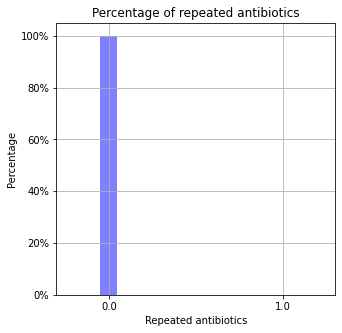

In [85]:
data['repeated_ABs'].value_counts(np.nan).sort_index().plot(kind='bar', figsize=(5, 5), rot=0, color = 'blue', alpha=0.5, width=0.1)
plt.xlabel('Repeated antibiotics')
plt.ylabel('Percentage')
plt.title('Percentage of repeated antibiotics')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.grid()
print(data['repeated_ABs'].value_counts().sort_index())
#plt.savefig(r'../output/hospitalisation_risk/repeated_ABs.png', edgecolor='none')
plt.show()

## Questions:
- I expect all dates to be within the one month period that the input data is supposedly generated/collected. How it is justified to have a date of 2020 (e.g. UTI diagnosis), while the data belongs to 2019? Is it becuase of having dummy data?
- Is our focus on repeated ABs for just one specific infection or any repeated ABs for any infection (LRTI and UTI)?